# GPGN268 - Geophysical Data Analysis
## Data Story 02 - Global Warming

**Student:** Addy Peterson

**Collaborators:**
- Jack Logan helped me debug on sections 3.1 and 3.2

**Date:** April 21, 2026

## Introduction

Argo floats are robotic floats that collect the "vital signs" of the oceans, including water temperature, salinity, and velocity. Just like weather balloons help scientists make conclusions about the atmosphere, the Argo Program helps scientists understand oceans. Different aspects are explored, from sea height to ocean circulation, allowing researchers to predict tropical storm seasons and make conclusions about climate change.

The data we are using comes from the International Argo Program between 2004 and 2019, which collected data from thousands of floats and interpolated to make a continuous map. Data is stored using a NetCDF (.nc) format, and includes 4 dimensions: time, pressure(depth), longitude, and latitude. Each profile has data for a specific variable as the float changes depth, documenting a 1D vertical column. These columns can be linked by time and location, showing changes over time, longitude, latitude, and depth, creating a 4D dataset. 

Formatting in this way is advantageous because other data like variables, dimensions, and units are also stored in the file, so critical information is stored with its corresponding data. This data format is also highly compatible with many different coding languages and is efficient for large data since users can use subsets without downloading the entire dataset. However, NetCDF is not readable for humans, so you must plot to "see" the data. Scientists typically use Python libraries like Xarray, Cartopy, and Matplotlib to analyze and interpret their float data.

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Task 2.1

In [ ]:
def read_data(path):

    ds_raw = xr.load_dataset(path) #load the dataset from the given path
    mean_pressure = ds_raw.PRES_ADJUSTED.mean(dim='N_PROF') #data reduction to simplify, makes 2D pressure array into 1D vector
    variables= ['TEMP_ADJUSTED','PSAL_ADJUSTED', 'LATITUDE', 'LONGITUDE', 'JULD'] #define variables of interest

    ds= ds_raw[variables] #pick and rename variables (easier to use later)
    ds = ds.rename({'JULD':'time'}).swap_dims({'N_PROF':'time'}) #swap dimensions to make profiles into a time series
    ds = ds.rename({'TEMP_ADJUSTED':'temperature',
                'PSAL_ADJUSTED':'salinity',
                'LATITUDE':'latitude',
                'LONGITUDE':'longitude'})
    
    ds['pressure'] = mean_pressure #collapse the entire profile into one mean pressure
    ds['pressure'].attrs['units'] = 'dbar'

    return ds

# each path is for a dataset
path_1= '../data/argo/1901487_prof.nc' 
path_2= '../data/argo/5901429_prof.nc'

ds_19= read_data(path_1)
ds_59=read_data(path_2)

print(ds_19) # checking it all looks good

<xarray.Dataset> Size: 126kB
Dimensions:      (time: 227, N_LEVELS: 66)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2010-10-13T09:40:57 ... 2017-04-08...
Dimensions without coordinates: N_LEVELS
Data variables:
    temperature  (time, N_LEVELS) float32 60kB 28.48 28.46 28.39 ... 5.281 5.161
    salinity     (time, N_LEVELS) float32 60kB 36.2 36.2 36.2 ... 34.88 34.89
    latitude     (time) float64 2kB 4.443 4.71 4.876 4.996 ... 8.433 9.853 9.819
    longitude    (time) float64 2kB -42.86 -42.64 -42.55 ... -54.43 -53.9 -53.78
    pressure     (N_LEVELS) float32 264B 5.0 10.0 15.0 ... 1.15e+03 1.2e+03
Attributes:
    title:                Argo float vertical profile
    institution:          FR GDAC
    source:               Argo float
    history:              2022-07-11T22:47:27Z creation
    references:           http://www.argodatamgt.org/Documentation
    user_manual_version:  3.1
    Conventions:          Argo-3.1 CF-1.6
    featureType:          trajectoryProfile


## Task 2.2

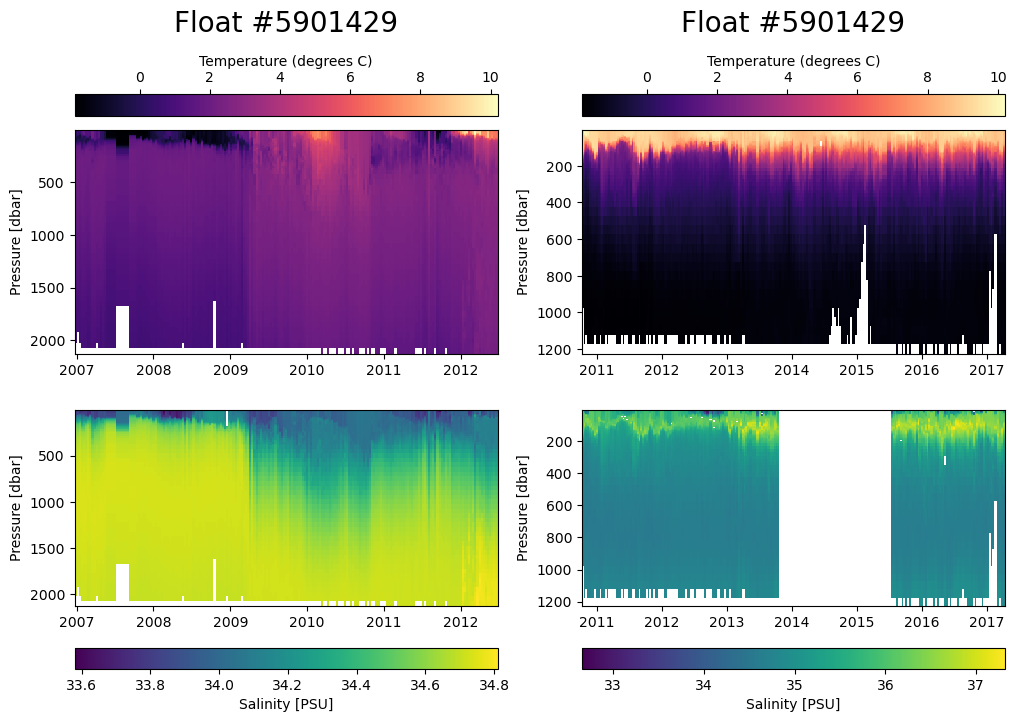

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey=False)
[ax1, ax2, ax3, ax4] = axes.flatten()

# LEFT PLOT (#59)

cs1 = ax1.pcolormesh(ds_59.time, ds_59.pressure, ds_59.temperature.T, cmap='magma')
cbar1 = plt.colorbar(cs1, ax=ax1,
                     location='top',
                     label='Temperature (degrees C)')
ax1.set_title("Float #5901429", y=1.4, fontsize=20)
ax1.set_ylabel('Pressure [dbar]')
ax1.invert_yaxis()

cs3 = ax3.pcolormesh(ds_59.time, ds_59.pressure, ds_59.salinity.T, cmap='viridis')
ax3.invert_yaxis()
ax3.set_ylabel('Pressure [dbar]')
cbar3 = fig.colorbar(cs3, ax=ax3, location='bottom', label='Salinity [PSU]')

# the left and right should be the same setup, but using different data
# RIGHT PLOT (#19)

cs2 = ax2.pcolormesh(ds_19.time, ds_19.pressure, ds_19.temperature.T, cmap='magma')
ax2.invert_yaxis()
ax2.set_title("Float #5901429", y=1.4, fontsize=20)
ax2.set_ylabel('Pressure [dbar]')
cbar2 = plt.colorbar(cs1, ax=ax2,
                     location='top',
                     label='Temperature (degrees C)')

cs4 = ax4.pcolormesh(ds_19.time, ds_19.pressure, ds_19.salinity.T, cmap='viridis')
ax4.invert_yaxis()
ax4.set_ylabel('Pressure [dbar]')
cbar4 = fig.colorbar(cs4, ax=ax4, location='bottom', label='Salinity [PSU]')

plt.show()

## Task 2.3

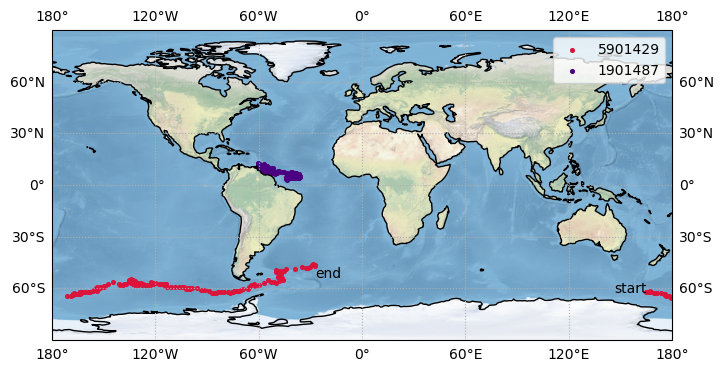

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection = ccrs.PlateCarree()) # which map we should use
ax.stock_img() #giv es the colors in the background
ax.add_feature(cfeature.COASTLINE) # bold coastline

ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle=':')

# plot the points in each color
ax.scatter(ds_59.longitude, ds_59.latitude, color='crimson', s=7, label='5901429', transform=ccrs.PlateCarree())
ax.scatter(ds_19.longitude, ds_19.latitude, color='indigo', s=7, label='1901487', transform=ccrs.PlateCarree())

# the text callouts
ax.text(ds_59.longitude[0], ds_59.latitude[0], 'start', 
        transform=ccrs.PlateCarree(), ha='right')
ax.text(ds_59.longitude[-1], ds_59.latitude[-1], 'end', 
        transform=ccrs.PlateCarree(), va='top')

# show legend
ax.legend(fontsize=10)
plt.show()

## Task 2.4

**Describe and interpret your results:** 

Both the vertical sections and trajectories of the Argo floats 5901429 and 1901487 reveal climate patterns for their respective region, which starkly contrast each other. Float 1901487 collected data in the Gulf of Mexico and eastward into the Atlantic Ocean. The vertical columns of this region show extreme stratification, with warm layers of over 25 degrees C confined to the upper 100 dbar. This distinct layer serves as a barrier to vertical mixting. The water in this area is also much more saline, peaking around 37 PSU, a pattern consistent with high evaporation rates from warm air that leave behind satly surface water. Contrastly, float 5901429 is recorded off the coast of Argentina and Antarctica, capturing much colder and fresher water. This float is travelling east and has a very deep and uniform cold layer. Cold water can be seen by the large, deep section of black on the temperature/pressure model. However, the entire column is very cold, with the top section remaining at about 5 degrees C. No distinct warm layer to stratify the column suggests vertical mixing. Salinity is low in this region from high precipitation and ice melt, only reaching about 34 PSU. 

These observations are very consistent with global patterns. In extreme latitudes, like float 5901429, the water column is nearly uniform in density, allowing cold water to sink, a force that drives the global ocean conveyor belt. At the equator, float 1901487 records a more thermally-driven system, where the sun creates a low-density surface layer that stratifies the layers of the vertical column. The contrasting sections show fundamental differences, from a salinity regulated and deeply mixed antarctic ocean climate to a temperature regulated and highly stratified tropical ocean climate.


## Task 2.5
- Discuss the assumption of independence of each data point. How good is this assumption? Could you propose something better? How would that change the confidence interval. You can just discuss in words, or do some exploration with code.

**Independence of each data point:** 

Data points are likely not independent of each other since ocean properties are not likely to change quickly. Things like temperature and salinity change very slowly, and a measurement taken today will likely be similar to one taken tomorrow, or even a week from now. It could be better to estimate the effective sample size, which estimates the sample size required from a random sample to achieve the same precision as a correlated sample. Simply, we could calculate a time scale that would make the data become independent. Since the data is correlated, the effective sample size is smaller than the number of profiles we have. In the CI formula, "n" is in the denominator, so a smaller "n" results in a wider confidence interval. The current plot likely underestimates the true certainty.

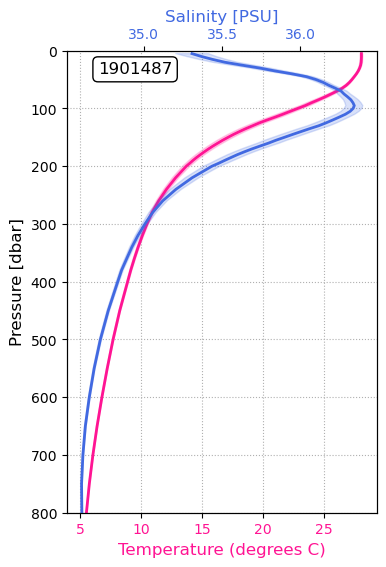

In [6]:
tropicaltemp = ds_19.temperature
tropicalsal = ds_19.salinity

#all the stats calculations to make the confidence interval
temp_mean= tropicaltemp.mean(dim='time')
sal_mean= tropicalsal.mean(dim='time')
temp_std= tropicaltemp.std(dim='time')
sal_std= tropicalsal.std(dim='time')

n = len(ds_19.time)
z_score= 1.96
temp_ci= z_score * (temp_std / np.sqrt(n))
sal_ci= z_score * (sal_std / np.sqrt(n))


#tropical colors hooray! taking creative liberty
fig, ax1 = plt.subplots(figsize=(4, 6))

color = 'deeppink'
ax1.plot(temp_mean, ds_19.pressure, color=color, linewidth=2)
ax1.fill_betweenx(ds_19.pressure, temp_mean - temp_ci, temp_mean + temp_ci, 
                  color=color, alpha=0.2) #the little color cloud around the line (confidence interval)
ax1.set_xlabel('Temperature (degrees C)', color=color, fontsize=12)
ax1.set_ylabel('Pressure [dbar]', fontsize=12)
ax1.set_ylim([0, 800])
ax1.invert_yaxis()
ax1.tick_params(axis='x', labelcolor=color)
ax1.grid(ls='dotted', which='both') #dotted grid lines

ax2 = ax1.twiny()
color = 'royalblue'
ax2.plot(sal_mean, ds_19.pressure, color=color, linewidth=2)
ax2.fill_betweenx(ds_19.pressure, sal_mean - sal_ci, sal_mean + sal_ci, 
                  color=color, alpha=0.2) #the little color cloud around the line (confidence interval)
ax2.set_xlabel('Salinity [PSU]', color=color, fontsize=12)
ax2.tick_params(axis='x', labelcolor=color)

ax1.text(0.1, 0.95, '1901487', transform=ax1.transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='white', alpha=1)) #round box with number

plt.show()

## Task 3.1

**What is the error?** The file type is a NetCDF (.nc), which records data in terms of "time units since...". If this set is in months and days, there are varying numbers of days in each month, so the computer doesn't know how to tell how many months ago something is. By adding "decode_times=false", we are telling the computer not to count how many months since an event, and to just give us raw data instead.

**What is ds?** The dataset is a 3D grid that has multiple dimensions, instead of a single float moving through time like the earlier profile data. The dimensions include time, pressure, longitude, and latitude. These work together to represent the normal state of the ocean at each point on the map during the time period. 

In [7]:
ds = xr.open_dataset('../data/RG_ArgoClim_Temperature_2019.nc', decode_times=False)

# Create a variable with the date of our first data point (origin)
t0 = np.datetime64("2004-01")
# Create a sequence representing the number 
# of months since 2004-01 ranging from 0 to 179
months = range(len(ds.TIME))
# Create and array of dates where you add 1...179 months 
# to the origin date t0
time = np.array([t0 + np.timedelta64(m, "M") for m in months])

ds = ds.rename({'TIME':'time'})
ds = ds.rename({'ARGO_TEMPERATURE_MEAN':'temp_mean',
                'ARGO_TEMPERATURE_ANOMALY':'temp_anom',
                'PRESSURE':'pressure',
                'LATITUDE':'latitude',
                'LONGITUDE':'longitude'})
# Replace the old values with the time array that we created
ds['time'] = time

## Task 3.2

**Describe and interpret your results:**

These plot show how much warmer or colder a season is compared to the average temperature in the region. Over the summer months (JJA), the Northern Hemisphere warms and the Southern Hemisphere cools. In winter months (DJF), the pattern flips and the Southern Hemisphere shows positive anomalies (warming), and the Northern Hemisphere cools down. Float 1901487 records less variation since its in the tropics and therefore experiences less seasonal variation.

In [ ]:
depth_ave_temp= ds.temp_anom.mean(dim='pressure')
seasonal_temp= depth_ave_temp.groupby("time.season").mean()

# Define limits for the colorbar
vmin = -1
vmax = 1
# Creates four subplots (2 rows and 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    cs = ax.pcolormesh(seasonal_temp.longitude, seasonal_temp.latitude,

                       seasonal_temp.sel(season=s),

                       transform = ccrs.PlateCarree(),

                       vmin=vmin,vmax=vmax,cmap='RdBu_r', shading= 'auto')
    ax.set_title(f"{s.values}",fontsize=14)
    ax.coastlines()
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray',
                  alpha=0.5, linestyle='dotted')
    gl.top_labels = False
    gl.right_labels = False

cax = fig.add_axes([0.99, 0.35, 0.02, 0.4])
cbar = plt.colorbar(cs, cax=cax,label='Temperature Anomaly (degrees C)')
fig.subplots_adjust(bottom=0.25, top=0.9, left=0.05, right=0.95,
                    wspace=0.3, hspace=0.01)
plt.show()

## Task 3.3
**Are the seasonal averages non-zero with statistical significance?**

Temperature anomalies with statistical significance are shown by a lack of hatching, visible in the stark red and blue patches in the Northern Atlantic and various parts of the Pacific. This means that climate changes stand out more than typical year by year changes. In places with lots of hatching, like the tropics, the "groupby" function calculated a number with variability high enough that we cannot confidently conclude that the mean is nonzero. In areas like the Pacific, where El Niño and La Niña take place, anomalies tend to be large and are easily deemed significant.

- Again, think about the assumption of **independent data**. How good is this assumption? Can you propose something better? How would that change your map?

Again, data is likely not independent since the ocean is so large and takes a long time to change significantly. An area that is warm in July will still be warm in August since water's high heat capacity traps heat for a long time. This changes our plots because we probably have much fewer degrees of freedom than we think. If there are 10 years of recorded data, maybe only 5 of those are truly independent, resulting in a Type 1 error (claiming significance where there is none). In reality, fewer regions should be statistically significant, so more would be covered in hatching. To adjust, I would follow the same alternative approach, calclating the effecive sample size to adapt to any correlation.

In [ ]:
from scipy import stats

def calculate_p_value(x):
    # t-test where null Hypothesis: the mean is 0
    t_stat, p_val = stats.ttest_1samp(x, 0, axis=0, nan_policy='propagate')
    return p_val

# group data by season
seasonal_p_values = xr.apply_ufunc(
    calculate_p_value,
    depth_ave_temp.groupby("time.season"),
    input_core_dims=[['time']],   # tells it to pass 'time' as the axis to collapse
    vectorize=True,               # applies the function element-wise over other dims
)

# filter insignificant data out using a mask
significant_mask = seasonal_p_values > 0.05

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, s in enumerate(seasonal_temp.season):
    ax = axes[i]
    data = seasonal_temp.sel(season=s)
    cs = ax.pcolormesh(seasonal_temp.longitude, seasonal_temp.latitude,
                       seasonal_temp.sel(season=s),
                       transform=ccrs.PlateCarree(),
                       vmin=-1, vmax=1, cmap='RdBu_r')
    
    # use mask for current season
    mask = significant_mask.sel(season=s)
    
    # use contourf to draw hatching where p > 0.05 (not significant)
    ax.pcolor(seasonal_temp.longitude, seasonal_temp.latitude, mask.where(mask==1),
                hatch='\\', 
                alpha=0,
                transform=ccrs.PlateCarree())
    
    ax.set_title(f"{s.values}", fontsize=14)
    ax.coastlines()

cax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
plt.colorbar(cs, cax=cax, label='Temperature Anomaly (degrees C)')
plt.show()

## Task 3.4
**What do you see in the data?** 

The blue line shows a regular seasonal cycle and the associated temperature oscillations. Changes are caused by differing amounts of ocean area, so when the Southern Hemisphere that has more water tilts towards the sun, the global average increases. The orange line shows overall change, disregarding seasonal fluxuation. From 2004 to 2012, the orange line wiggles around an average temperature anomaly, but from 2012 to 2018 the orange line trends upward, showing a global increase in temperature anomaly. In short, the ocean began to rapidly warm.

**Temperature trend analysis:**

To calculate change in degrees over change in time, we can estimate the following:
- Initial anomaly (2012): -0.01 degrees C
- Final anomaly (2018): 0.05 degrees C
This gives us a total change of 0.06 degrees C over 6.5 years (early 2012 to late 2018). 
- Rate = (0.06 degrees C)/ (6.5 years) ~ 0.00932 degrees C/year. Over 10 years, the trend is *0.092 degrees C/decade.*

**Compare to other reports:**

Around 0.1 degrees C/decade is reasonable, compared with NOAA and IPCC AR6 [1,2] reports that cite between 0.7 and 0.15 degrees C/decade, and also note acceleration after around 2010. 

**References:**

[1] R. Lindsey and L. Dahlman, "Climate Change: Ocean Heat Content," NOAA Climate.gov, Aug. 2023. [Online]. Available: https://www.climate.gov/news-features/understanding-climate/climate-change-ocean-heat-content

[2] IPCC, "Summary for Policymakers," in Climate Change 2021: The Physical Science Basis. Contribution of Working Group I to the Sixth Assessment Report of the Intergovernmental Panel on Climate Change, V. Masson-Delmotte et al., Eds. Cambridge, UK: Cambridge University Press, 2021, pp. 3–32. [Online]. Available: https://www.ipcc.ch/report/ar6/wg1/




In [ ]:
depth_ave_temp= ds.temp_anom.mean(dim='pressure')

global_mean = depth_ave_temp.temp_anom.mean(dim=['latitude', 'longitude'])
running_mean = global_mean.rolling(time=12, center=True).mean()

plt.figure(figsize=(10, 6))

global_mean.plot(label='mean ocean temperature', color='dodgerblue', linewidth=1.5)

running_mean.plot(label='12-month smoothing', color='tomato', linewidth=2)

plt.ylabel("Temperature anomaly [degrees C]", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.ylim(-0.1, 0.11)

plt.show()